In [9]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt


current_dir = Path().resolve()

my_code_path = str(current_dir / "src_copy")
if my_code_path not in sys.path:
    sys.path.insert(0, my_code_path)

from market_data import *
from model import *
from enums import *
from pricer import *
from contract import *

project_root = current_dir.parents[2]
MarketData.market_folder = str(project_root / "mkt")

MarketData.initialize()

In [46]:
und = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[und]
expiry = 1
strike = 130

vol = MarketData.get_volgrid()[und].get_vol(np.array([[strike, expiry]]))[0]

contract = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike, expiry)

model = FlatVolModel(und)

params = Params()
pricer = EuropeanAnalyticPricer(contract, model, params)

analytic_delta = pricer.calc_delta(GreekMethod.ANALYTIC)

print(f"Analytical delta: {analytic_delta:.4f}")

Analytical delta: 0.6275


Strikes: [ 90. 100. 110. 120. 125. 130. 135. 140. 150. 160. 170.]


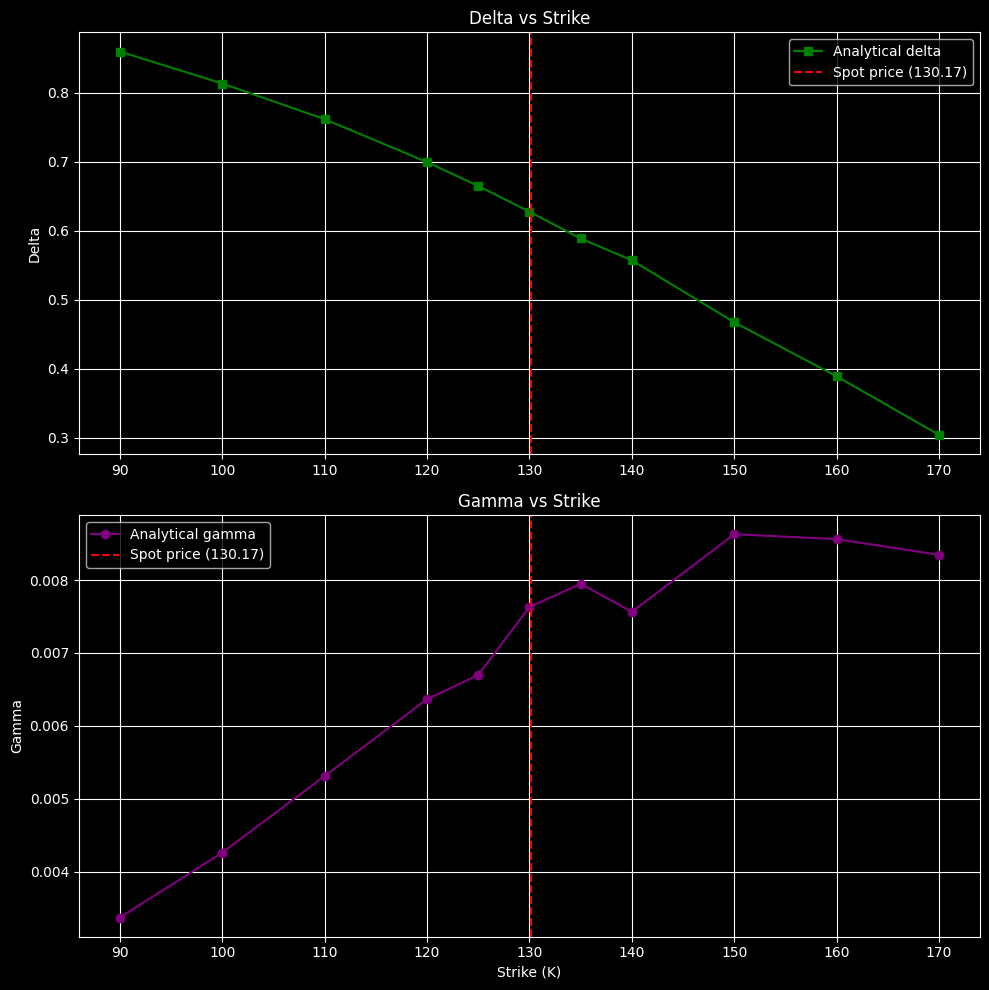

In [45]:
volgrid = MarketData.get_volgrid()[und]
strikes = np.unique(volgrid.points[:, 0])
strikes.sort()

print(f"Strikes: {strikes}")

model = FlatVolModel(und)
params = Params()

analytic_deltas = []
analytic_gammas = []

for K in strikes:
    vol_k = volgrid.get_vol(np.array([[K, expiry]]))[0]
    contract_k = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, K, expiry)
    pricer_k = EuropeanAnalyticPricer(contract_k, model, Params())

    analytic_deltas.append(pricer_k.calc_delta(GreekMethod.ANALYTIC))
    analytic_gammas.append(pricer_k.calc_gamma(GreekMethod.ANALYTIC))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(strikes, analytic_deltas, 's-', color='green', label='Analytical delta')
ax1.axvline(x=spot, color='r', linestyle='--', label=f'Spot price ({spot:.2f})')
ax1.set_title('Delta vs Strike')
ax1.set_ylabel('Delta')
ax1.legend()
ax1.grid(True)

ax2.plot(strikes, analytic_gammas, 'o-', color='purple', label='Analytical gamma')
ax2.axvline(x=spot, color='r', linestyle='--', label=f'Spot price ({spot:.2f})')
ax2.set_title('Gamma vs Strike')
ax2.set_xlabel('Strike (K)')
ax2.set_ylabel('Gamma')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Analytical delta: 0.627471


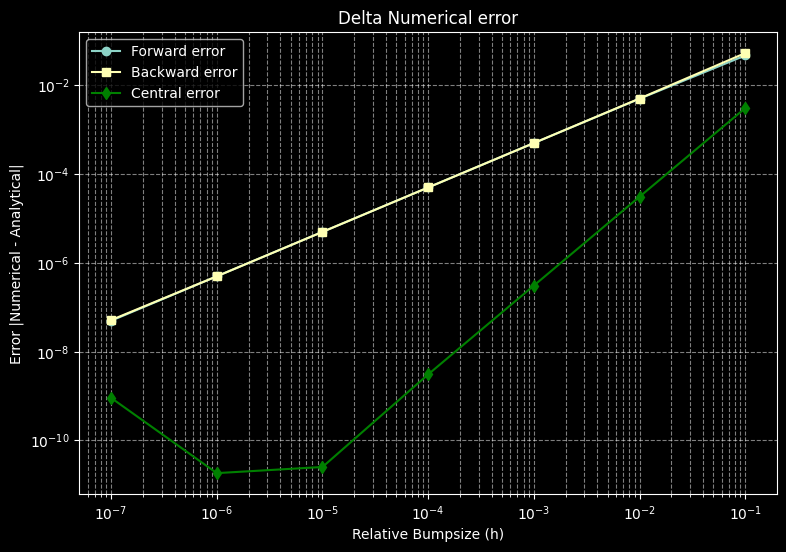

Optimal bump size: 1e-06


In [44]:
strike = 130
expiry = 1

contract_test = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike, expiry)
pricer_test = EuropeanAnalyticPricer(contract_test, model, params)


exact_delta = pricer_test.calc_delta(GreekMethod.ANALYTIC)
print(f"Analytical delta: {exact_delta:.6f}")

bumps = [0.1, 0.01, 0.001, 0.0001, 1e-5, 1e-6, 1e-7]

err_forward = []
err_backward = []
err_central = []

pricer_test.bump_type = BumpType.RELATIVE

for h in bumps:
    pricer_test.relative_bump_size = h

    # FORWARD
    pricer_test.fd_method = FiniteDifferenceMethod.FORWARD
    num_fwd = pricer_test.calc_delta(GreekMethod.BUMP)
    err_forward.append(abs(num_fwd - exact_delta))

    # BACKWARD
    pricer_test.fd_method = FiniteDifferenceMethod.BACKWARD
    num_bwd = pricer_test.calc_delta(GreekMethod.BUMP)
    err_backward.append(abs(num_bwd - exact_delta))

    # CENTRAL
    pricer_test.fd_method = FiniteDifferenceMethod.CENTRAL
    num_cen = pricer_test.calc_delta(GreekMethod.BUMP)
    err_central.append(abs(num_cen - exact_delta))

plt.figure(figsize=(9, 6))
plt.loglog(bumps, err_forward, 'o-', label='Forward error')
plt.loglog(bumps, err_backward, 's-', label='Backward error')
plt.loglog(bumps, err_central, 'd-', color='green', label='Central error')

plt.title('Delta Numerical error')
plt.xlabel('Relative Bump size (h)')
plt.ylabel('Error |Numerical - Analytical|')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

best_index = err_central.index(min(err_central))
perfect_h = bumps[best_index]

print(f"Optimal bump size: {perfect_h}")

Analytical delta: 0.627471


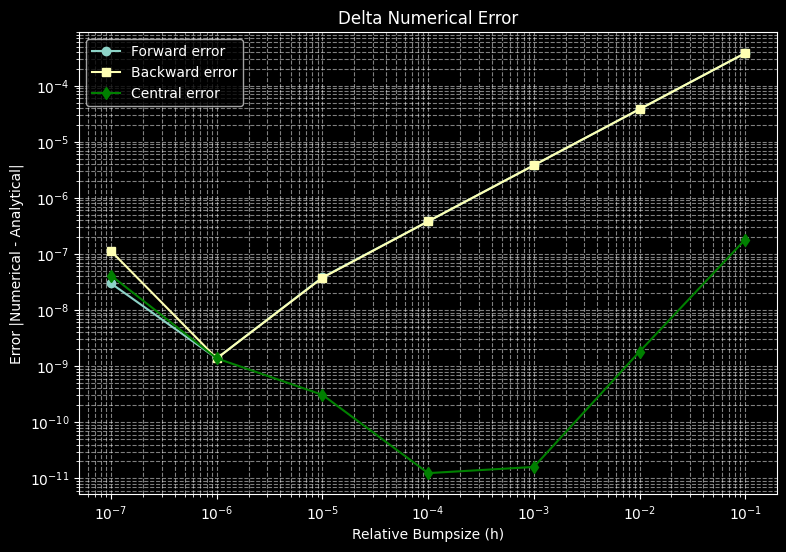

Optimal bump size: 0.0001


In [48]:
strike = 130
expiry = 1

contract_test = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike, expiry)
pricer_test = EuropeanAnalyticPricer(contract_test, model, params)


exact_delta = pricer_test.calc_delta(GreekMethod.ANALYTIC)
print(f"Analytical delta: {exact_delta:.6f}")

bumps = [0.1, 0.01, 0.001, 0.0001, 1e-5, 1e-6, 1e-7]

err_forward = []
err_backward = []
err_central = []

pricer_test.bump_type = BumpType.ABSOLUTE

for h in bumps:
    pricer_test.absolute_bump_size = h

    # FORWARD
    pricer_test.fd_method = FiniteDifferenceMethod.FORWARD
    num_fwd = pricer_test.calc_delta(GreekMethod.BUMP)
    err_forward.append(abs(num_fwd - exact_delta))

    # BACKWARD
    pricer_test.fd_method = FiniteDifferenceMethod.BACKWARD
    num_bwd = pricer_test.calc_delta(GreekMethod.BUMP)
    err_backward.append(abs(num_bwd - exact_delta))

    # CENTRAL
    pricer_test.fd_method = FiniteDifferenceMethod.CENTRAL
    num_cen = pricer_test.calc_delta(GreekMethod.BUMP)
    err_central.append(abs(num_cen - exact_delta))

plt.figure(figsize=(9, 6))
plt.loglog(bumps, err_forward, 'o-', label='Forward error')
plt.loglog(bumps, err_backward, 's-', label='Backward error')
plt.loglog(bumps, err_central, 'd-', color='green', label='Central error')

plt.title('Delta Numerical Error')
plt.xlabel('Relative Bump size (h)')
plt.ylabel('Error |Numerical - Analytical|')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

best_index = err_central.index(min(err_central))
perfect_h = bumps[best_index]

print(f"Optimal bump size: {perfect_h}")

Analytical Gamma: 0.007630


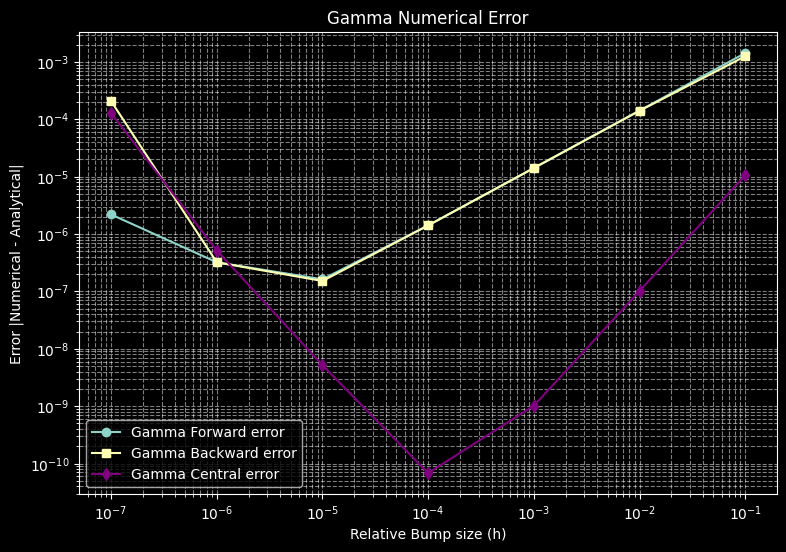

Optimal bump size: 0.0001


In [51]:
exact_gamma = pricer_test.calc_gamma(GreekMethod.ANALYTIC)
print(f"Analytical Gamma: {exact_gamma:.6f}")

err_gamma_fwd = []
err_gamma_bwd = []
err_gamma_cen = []

pricer_test.bump_type = BumpType.RELATIVE

for h in bumps:
    pricer_test.relative_bump_size = h

    # FORWARD
    pricer_test.fd_method = FiniteDifferenceMethod.FORWARD
    num_gamma_fwd = pricer_test.calc_gamma(GreekMethod.BUMP)
    err_gamma_fwd.append(abs(num_gamma_fwd - exact_gamma))

    # BACKWARD
    pricer_test.fd_method = FiniteDifferenceMethod.BACKWARD
    num_gamma_bwd = pricer_test.calc_gamma(GreekMethod.BUMP)
    err_gamma_bwd.append(abs(num_gamma_bwd - exact_gamma))

    # CENTRAL
    pricer_test.fd_method = FiniteDifferenceMethod.CENTRAL
    num_gamma_cen = pricer_test.calc_gamma(GreekMethod.BUMP)
    err_gamma_cen.append(abs(num_gamma_cen - exact_gamma))

plt.figure(figsize=(9, 6))
plt.loglog(bumps, err_gamma_fwd, 'o-', label='Gamma Forward error')
plt.loglog(bumps, err_gamma_bwd, 's-', label='Gamma Backward error')
plt.loglog(bumps, err_gamma_cen, 'd-', color='purple', label='Gamma Central error')

plt.title('Gamma Numerical Error')
plt.xlabel('Relative Bump size (h)')
plt.ylabel('Error |Numerical - Analytical|')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

best_idx_gamma = err_gamma_cen.index(min(err_gamma_cen))
print(f"Optimal bump size: {bumps[best_idx_gamma]}")

Analytical Gamma: 0.007630


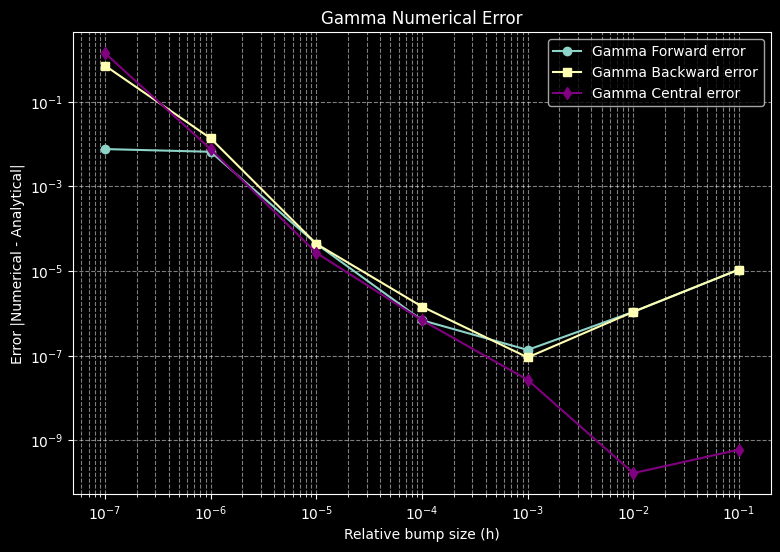

Optimal bump size: 0.01


In [53]:
exact_gamma = pricer_test.calc_gamma(GreekMethod.ANALYTIC)
print(f"Analytical Gamma: {exact_gamma:.6f}")

err_gamma_fwd = []
err_gamma_bwd = []
err_gamma_cen = []

pricer_test.bump_type = BumpType.ABSOLUTE

for h in bumps:
    pricer_test.absolute_bump_size = h

    # FORWARD
    pricer_test.fd_method = FiniteDifferenceMethod.FORWARD
    num_gamma_fwd = pricer_test.calc_gamma(GreekMethod.BUMP)
    err_gamma_fwd.append(abs(num_gamma_fwd - exact_gamma))

    # BACKWARD
    pricer_test.fd_method = FiniteDifferenceMethod.BACKWARD
    num_gamma_bwd = pricer_test.calc_gamma(GreekMethod.BUMP)
    err_gamma_bwd.append(abs(num_gamma_bwd - exact_gamma))

    # CENTRAL
    pricer_test.fd_method = FiniteDifferenceMethod.CENTRAL
    num_gamma_cen = pricer_test.calc_gamma(GreekMethod.BUMP)
    err_gamma_cen.append(abs(num_gamma_cen - exact_gamma))

plt.figure(figsize=(9, 6))
plt.loglog(bumps, err_gamma_fwd, 'o-', label='Gamma Forward error')
plt.loglog(bumps, err_gamma_bwd, 's-', label='Gamma Backward error')
plt.loglog(bumps, err_gamma_cen, 'd-', color='purple', label='Gamma Central error')
plt.title('Gamma Numerical Error')
plt.xlabel('Relative bump size (h)')
plt.ylabel('Error |Numerical - Analytical|')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

best_idx_gamma = err_gamma_cen.index(min(err_gamma_cen))
print(f"Optimal bump size: {bumps[best_idx_gamma]}")

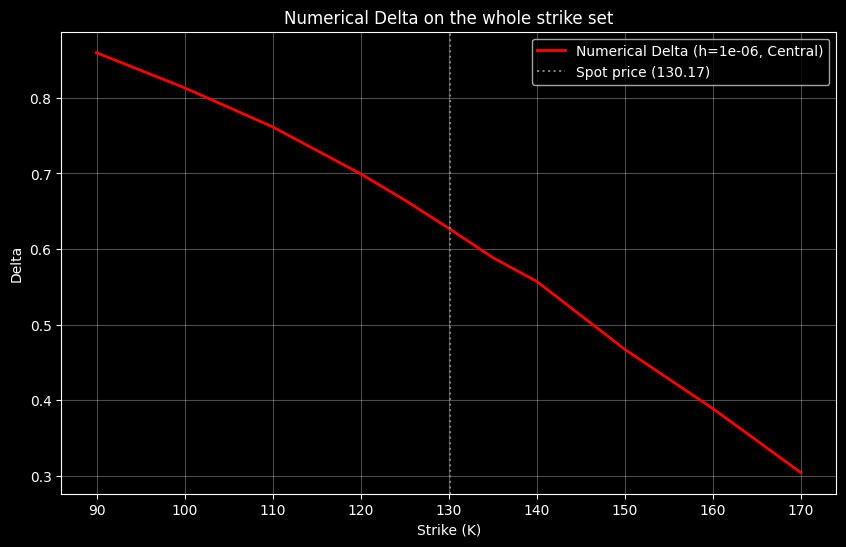

In [55]:
h_fixed = 1e-6
numerical_deltas = []

for K in strikes:
    contract_k = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, K, expiry)
    pricer_k = EuropeanAnalyticPricer(contract_k, model, params)

    pricer_k.bump_type = BumpType.RELATIVE
    pricer_k.fd_method = FiniteDifferenceMethod.CENTRAL
    pricer_k.relative_bump_size = h_fixed
    numerical_deltas.append(pricer_k.calc_delta(GreekMethod.BUMP))

plt.figure(figsize=(10, 6))
plt.plot(strikes, numerical_deltas, label=f'Numerical Delta (h={h_fixed}, Central)', color='red', linewidth=2)

plt.axvline(x=spot, color='gray', linestyle=':', label=f'Spot price ({spot:.2f})')
plt.title('Numerical Delta on the whole strike set')
plt.xlabel('Strike (K)')
plt.ylabel('Delta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

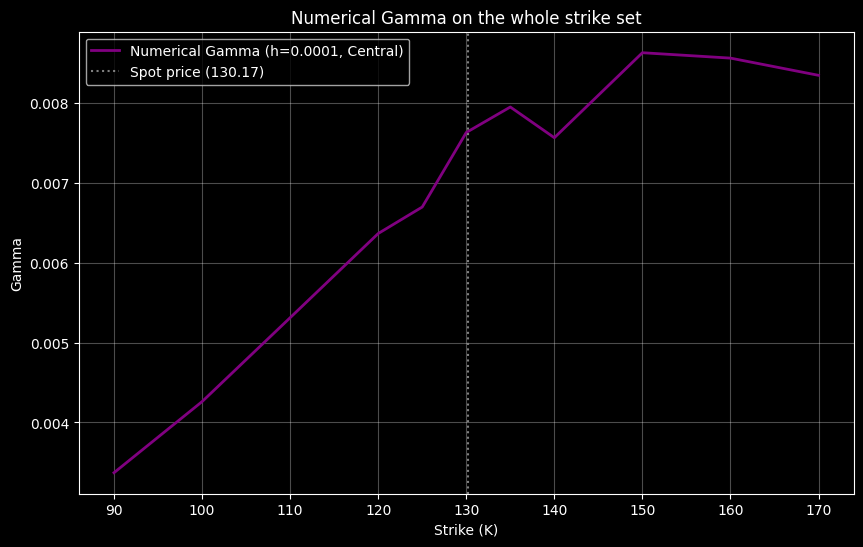

In [56]:
h_gamma = 1e-4
numerical_gammas = []

for K in strikes:
    contract_k = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, K, expiry)
    pricer_k = EuropeanAnalyticPricer(contract_k, model, params)

    pricer_k.bump_type = BumpType.RELATIVE
    pricer_k.fd_method = FiniteDifferenceMethod.CENTRAL
    pricer_k.relative_bump_size = h_gamma
    numerical_gammas.append(pricer_k.calc_gamma(GreekMethod.BUMP))


plt.figure(figsize=(10, 6))
plt.plot(strikes, numerical_gammas, label=f'Numerical Gamma (h={h_gamma}, Central)', color='purple', linewidth=2)
plt.axvline(x=spot, color='gray', linestyle=':', label=f'Spot price ({spot:.2f})')
plt.title('Numerical Gamma on the whole strike set')
plt.xlabel('Strike (K)')
plt.ylabel('Gamma')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()